<a href="https://colab.research.google.com/github/AhmedEsammohmaed/IBS/blob/main/cubicasa5k_floorplan_cv.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CubiCasa5K — Floor Plan Understanding (End-to-End Colab Notebook)

Dataset: [`qmarva/cubicasa5k`](https://www.kaggle.com/datasets/qmarva/cubicasa5k/data)

This single notebook covers all four target tasks:

| # | Task | Approach |
|---|------|----------|
| 1 | **Wall / room segmentation** | Multi-task U-Net (ResNet-34 encoder), 12-class room head |
| 2 | **Icon detection** (doors, windows, sinks, …) | 11-class icon head + connected-component instance extraction → bounding boxes |
| 3 | **Room type classification + area estimation** | Per-room-instance majority vote on the room head + pixel counting scaled by px→metre factor |
| 4 | **Vectorization to polygons / JSON** | Contour tracing + Douglas–Peucker simplification + rectilinear snapping → structured JSON |

**Design choice:** a *single* shared-encoder network with two segmentation heads (rooms + icons),
exactly the multi-task formulation the CubiCasa5K paper uses, but with a modern pretrained
encoder from `segmentation_models_pytorch`. This is far easier to train than the original
hourglass network and gives strong results in ~10 epochs on a Colab T4. Tasks 3 and 4 are
*derived* from the segmentation output by classical CV — no extra training needed.

**Runtime:** set `Runtime → Change runtime type → GPU (T4)` before running.

## 0. Environment setup

In [1]:
!nvidia-smi -L || echo "No GPU — go to Runtime > Change runtime type > GPU"

GPU 0: Tesla T4 (UUID: GPU-55671ac0-d6df-0dfa-d737-f6dbef2de003)


In [2]:
%pip -q install segmentation-models-pytorch==0.3.4 albumentations==1.4.15 \
                opencv-python-headless shapely lxml svgpathtools kaggle tqdm
print("deps installed")

deps installed


In [3]:
import os, json, math, random, time, warnings
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("torch", torch.__version__, "| device:", DEVICE)

torch 2.11.0+cu128 | device: cuda


## 1. Get the dataset from Kaggle

Upload your `kaggle.json` (Kaggle → Account → *Create New API Token*) when prompted.
The archive is ~7 GB, so download takes a few minutes.

In [4]:
from google.colab import files

if not Path("/root/.kaggle/kaggle.json").exists():
    print("Upload kaggle.json:")
    up = files.upload()
    os.makedirs("/root/.kaggle", exist_ok=True)
    with open("/root/.kaggle/kaggle.json", "wb") as f:
        f.write(next(iter(up.values())))
os.chmod("/root/.kaggle/kaggle.json", 0o600)
print("kaggle credentials ready")

kaggle credentials ready


In [5]:
DATA_ROOT = Path("/content/cubicasa5k")

if not DATA_ROOT.exists():
    !kaggle datasets download -d qmarva/cubicasa5k -p /content --unzip
    # the archive may unzip into a nested folder; normalise the path
    for cand in [Path("/content/cubicasa5k"), Path("/content/cubicasa5k/cubicasa5k")]:
        if (cand / "train.txt").exists() or (cand / "high_quality").exists():
            DATA_ROOT = cand
            break

print("DATA_ROOT =", DATA_ROOT)
print(sorted(p.name for p in DATA_ROOT.iterdir())[:20])

DATA_ROOT = /content/cubicasa5k
['cubicasa5k']


In [6]:
# Locate the split files and sanity-check one sample folder.
def find_splits(root: Path):
    out = {}
    for name in ["train", "val", "test"]:
        hits = list(root.rglob(f"{name}.txt"))
        if hits:
            out[name] = hits[0]
    return out

SPLITS = find_splits(DATA_ROOT)
print("split files:", {k: str(v) for k, v in SPLITS.items()})

def read_split(p: Path):
    return [ln.strip() for ln in p.read_text().splitlines() if ln.strip()]

train_ids = read_split(SPLITS["train"])
val_ids   = read_split(SPLITS["val"])
test_ids  = read_split(SPLITS["test"])
print(f"train={len(train_ids)}  val={len(val_ids)}  test={len(test_ids)}")
print("example id:", train_ids[0])

SPLIT_BASE = SPLITS["train"].parent          # ids are relative to this folder
sample_dir = SPLIT_BASE / train_ids[0].strip("/")
print("sample folder contents:", sorted(p.name for p in sample_dir.iterdir()))

split files: {'train': '/content/cubicasa5k/cubicasa5k/train.txt', 'val': '/content/cubicasa5k/cubicasa5k/val.txt', 'test': '/content/cubicasa5k/cubicasa5k/test.txt'}
train=4200  val=400  test=400
example id: /high_quality_architectural/6044/
sample folder contents: ['F1_original.png', 'F1_scaled.png', 'model.svg']


## 2. Label schema

CubiCasa5K annotations live in `model.svg` per sample. Rooms and icons are separate
label spaces, which is why we use two heads.

In [7]:
ROOM_CLASSES = [
    "Background", "Outdoor", "Wall", "Kitchen", "Living Room", "Bedroom",
    "Bath", "Entry", "Railing", "Storage", "Garage", "Other Rooms",
]
ICON_CLASSES = [
    "No Icon", "Window", "Door", "Closet", "Electr. Appl.", "Toilet",
    "Sink", "Sauna Bench", "Fire Place", "Bathtub", "Chimney",
]
N_ROOM, N_ICON = len(ROOM_CLASSES), len(ICON_CLASSES)
WALL_ID = ROOM_CLASSES.index("Wall")

# Rooms whose floor area counts toward the habitable total (task 3).
AREA_ROOMS = {"Kitchen", "Living Room", "Bedroom", "Bath", "Entry", "Storage", "Other Rooms"}

# Distinct colours for visualisation (BGR-free, matplotlib RGB 0-1).
def palette(n, seed=7):
    rng = np.random.default_rng(seed)
    cols = rng.uniform(0.15, 0.95, size=(n, 3))
    cols[0] = (1.0, 1.0, 1.0)   # background white
    return cols

ROOM_PAL, ICON_PAL = palette(N_ROOM), palette(N_ICON, seed=3)

def colorize(mask, pal):
    return pal[np.clip(mask, 0, len(pal) - 1)]

print(dict(rooms=N_ROOM, icons=N_ICON, wall_id=WALL_ID))

{'rooms': 12, 'icons': 11, 'wall_id': 2}


## 3. SVG annotation parser

Each `model.svg` contains `<g class="Wall ...">`, `<g class="Space Kitchen">`,
`<g class="Door ...">` groups whose `<polygon points="...">` children give the geometry.
We rasterise those polygons into two label maps and also recover the **pixel→metre scale**
from the wall thickness / `FixedFurniture` metadata when present.

In [8]:
from lxml import etree

# SVG class-name aliases -> our canonical class names.
ROOM_ALIAS = {
    "outdoor": "Outdoor", "garden": "Outdoor", "balcony": "Outdoor", "terrace": "Outdoor",
    "wall": "Wall", "railing": "Railing",
    "kitchen": "Kitchen", "diningroom": "Living Room", "livingroom": "Living Room",
    "draughtlobby": "Entry", "entry": "Entry", "hall": "Entry",
    "bedroom": "Bedroom", "bed": "Bedroom",
    "bath": "Bath", "sauna": "Bath", "wc": "Bath", "washingroom": "Bath",
    "storage": "Storage", "closet": "Storage", "walkincloset": "Storage",
    "garage": "Garage", "carport": "Garage",
}
ICON_ALIAS = {
    "window": "Window", "door": "Door", "closet": "Closet",
    "electricalappliance": "Electr. Appl.", "appliance": "Electr. Appl.",
    "toilet": "Toilet", "wc": "Toilet",
    "sink": "Sink", "washbasin": "Sink",
    "saunabench": "Sauna Bench", "fireplace": "Fire Place",
    "bathtub": "Bathtub", "chimney": "Chimney",
}

def _norm(tok: str) -> str:
    return "".join(ch for ch in tok.lower() if ch.isalnum())

def _polys(node):
    """All polygon/rect point arrays inside an SVG group, as float arrays."""
    out = []
    for poly in node.iter():
        tag = etree.QName(poly).localname
        if tag == "polygon" and poly.get("points"):
            nums = [float(v) for v in poly.get("points").replace(",", " ").split()]
            if len(nums) >= 6:
                out.append(np.array(nums, dtype=np.float32).reshape(-1, 2))
        elif tag == "rect":
            x, y = float(poly.get("x", 0)), float(poly.get("y", 0))
            w, h = float(poly.get("width", 0)), float(poly.get("height", 0))
            if w > 0 and h > 0:
                out.append(np.array([[x, y], [x + w, y], [x + w, y + h], [x, y + h]], np.float32))
    return out

def parse_svg(svg_path: Path, hw):
    """Rasterise a CubiCasa model.svg into (room_mask, icon_mask, meta)."""
    H, W = hw
    room = np.zeros((H, W), np.uint8)
    icon = np.zeros((H, W), np.uint8)
    tree = etree.parse(str(svg_path))
    root = tree.getroot()

    # Scale SVG user units -> pixel grid of the rasterised plan.
    vb = root.get("viewBox")
    sx = sy = 1.0
    if vb:
        _, _, vw, vh = [float(v) for v in vb.replace(",", " ").split()]
        if vw > 0 and vh > 0:
            sx, sy = W / vw, H / vh

    def draw(mask, polys, cid):
        for p in polys:
            q = np.stack([p[:, 0] * sx, p[:, 1] * sy], 1)
            cv2.fillPoly(mask, [np.round(q).astype(np.int32)], int(cid))

    wall_widths = []
    # Pass 1: spaces (floor areas). Pass 2: walls/railings. Pass 3: icons — later passes win.
    groups = [g for g in root.iter() if etree.QName(g).localname == "g"]

    for g in groups:  # spaces
        toks = [_norm(t) for t in (g.get("class") or "").split()]
        if "space" not in toks:
            continue
        name = next((ROOM_ALIAS[t] for t in toks if t in ROOM_ALIAS), None)
        cid = ROOM_CLASSES.index(name) if name else ROOM_CLASSES.index("Other Rooms")
        draw(room, _polys(g), cid)

    for g in groups:  # structure
        toks = [_norm(t) for t in (g.get("class") or "").split()]
        if "wall" in toks or "railing" in toks:
            cid = ROOM_CLASSES.index("Railing" if "railing" in toks else "Wall")
            ps = _polys(g)
            draw(room, ps, cid)
            for p in ps:                       # remember thickness for the scale estimate
                r = cv2.minAreaRect(p.astype(np.float32))
                wall_widths.append(min(r[1]))

    for g in groups:  # icons / fixtures
        toks = [_norm(t) for t in (g.get("class") or "").split()]
        name = next((ICON_ALIAS[t] for t in toks if t in ICON_ALIAS), None)
        if name is None:
            continue
        draw(icon, _polys(g), ICON_CLASSES.index(name))

    # Scale: interior walls in Finnish housing stock are ~0.1 m; use the median
    # wall thickness as the reference length. Fallback keeps areas comparable.
    med_w = float(np.median(wall_widths)) * ((sx + sy) / 2) if wall_widths else 0.0
    px_per_m = (med_w / 0.10) if med_w > 2 else 40.0
    return room, icon, {"px_per_m": px_per_m, "median_wall_px": med_w}

print("parser ready")

parser ready


## 4. Dataset & augmentation

In [9]:
%pip install --upgrade albumentations albucore

  Using cached albumentations-2.0.8-py3-none-any.whl.metadata (43 kB)
  Using cached albucore-0.2.16-py3-none-any.whl.metadata (19 kB)
Using cached albumentations-2.0.8-py3-none-any.whl (369 kB)
  Attempting uninstall: albumentations
    Found existing installation: albumentations 1.4.15
    Uninstalling albumentations-1.4.15:
      Successfully uninstalled albumentations-1.4.15


In [10]:
import albumentations as A
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from pathlib import Path

IMG_SIZE = 512

train_tf = A.Compose([
    A.LongestMaxSize(max_size=IMG_SIZE),
    A.PadIfNeeded(min_height=IMG_SIZE, min_width=IMG_SIZE, border_mode=cv2.BORDER_CONSTANT, value=255, mask_value=0),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.2),
    A.RandomRotate90(p=0.5),
    # Fixed keyword arguments for compatibility with recent Albumentations releases:
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.3),
], additional_targets={"icon": "mask"})

eval_tf = A.Compose([
    A.LongestMaxSize(max_size=IMG_SIZE),
    A.PadIfNeeded(min_height=IMG_SIZE, min_width=IMG_SIZE, border_mode=cv2.BORDER_CONSTANT, value=255, mask_value=0),
], additional_targets={"icon": "mask"})

In [11]:
import albumentations as A

IMG_SIZE = 512

train_tf = A.Compose([
    A.LongestMaxSize(IMG_SIZE),
    A.PadIfNeeded(IMG_SIZE, IMG_SIZE, border_mode=cv2.BORDER_CONSTANT, value=255, mask_value=0),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.2),
    A.RandomRotate90(p=0.5),
    A.RandomBrightnessContrast(0.2, 0.2, p=0.3),
], additional_targets={"icon": "mask"})

eval_tf = A.Compose([
    A.LongestMaxSize(IMG_SIZE),
    A.PadIfNeeded(IMG_SIZE, IMG_SIZE, border_mode=cv2.BORDER_CONSTANT, value=255, mask_value=0),
], additional_targets={"icon": "mask"})

MEAN = np.array([0.485, 0.456, 0.406], np.float32)
STD  = np.array([0.229, 0.224, 0.225], np.float32)


class CubiCasa(Dataset):
    """Reads <sample>/F1_scaled.png (falls back to any png) + model.svg."""

    IMG_CANDIDATES = ["F1_scaled.png", "F1_original.png", "F1_scaled.jpg"]

    def __init__(self, ids, base: Path, tf, cache_dir="/content/cache"):
        self.base, self.tf = Path(base), tf
        self.cache = Path(cache_dir); self.cache.mkdir(parents=True, exist_ok=True)
        self.items = []
        for i in ids:
            d = self.base / i.strip("/")
            img = next((d / c for c in self.IMG_CANDIDATES if (d / c).exists()), None)
            if img is None:
                pngs = sorted(d.glob("*.png"))
                img = pngs[0] if pngs else None
            svg = d / "model.svg"
            if img is not None and svg.exists():
                self.items.append((img, svg, i.strip("/").replace("/", "__")))
        print(f"{len(self.items)}/{len(ids)} samples usable")

    def __len__(self):
        return len(self.items)

    def _labels(self, img_path, svg_path, key, hw):
        """Rasterised labels are cached as npz — SVG parsing is the bottleneck."""
        f = self.cache / f"{key}_{hw[0]}x{hw[1]}.npz"
        if f.exists():
            z = np.load(f)
            return z["room"], z["icon"], float(z["px_per_m"])
        room, icon, meta = parse_svg(svg_path, hw)
        np.savez_compressed(f, room=room, icon=icon, px_per_m=meta["px_per_m"])
        return room, icon, meta["px_per_m"]

    def __getitem__(self, k):
        img_path, svg_path, key = self.items[k]
        img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
        # Cap very large plans so SVG rasterisation stays cheap.
        if max(img.shape[:2]) > 1024:
            s = 1024 / max(img.shape[:2])
            img = cv2.resize(img, None, fx=s, fy=s, interpolation=cv2.INTER_AREA)
        room, icon, px_per_m = self._labels(img_path, svg_path, key, img.shape[:2])

        out = self.tf(image=img, mask=room, icon=icon)
        x = ((out["image"].astype(np.float32) / 255.0) - MEAN) / STD
        return (
            torch.from_numpy(x.transpose(2, 0, 1)),
            torch.from_numpy(out["mask"].astype(np.int64)),
            torch.from_numpy(out["icon"].astype(np.int64)),
            torch.tensor(px_per_m * IMG_SIZE / max(img.shape[:2]), dtype=torch.float32),
        )


# Start with a subset so the first full pass is quick; raise these for real training.
N_TRAIN, N_VAL = 1200, 200
ds_train = CubiCasa(train_ids[:N_TRAIN], SPLIT_BASE, train_tf)
ds_val   = CubiCasa(val_ids[:N_VAL],   SPLIT_BASE, eval_tf)

dl_train = DataLoader(ds_train, batch_size=6, shuffle=True,  num_workers=2,
                      pin_memory=True, drop_last=True, persistent_workers=True)
dl_val   = DataLoader(ds_val,   batch_size=6, shuffle=False, num_workers=2, pin_memory=True)
print("batches:", len(dl_train), len(dl_val))

1200/1200 samples usable
200/200 samples usable
batches: 200 34


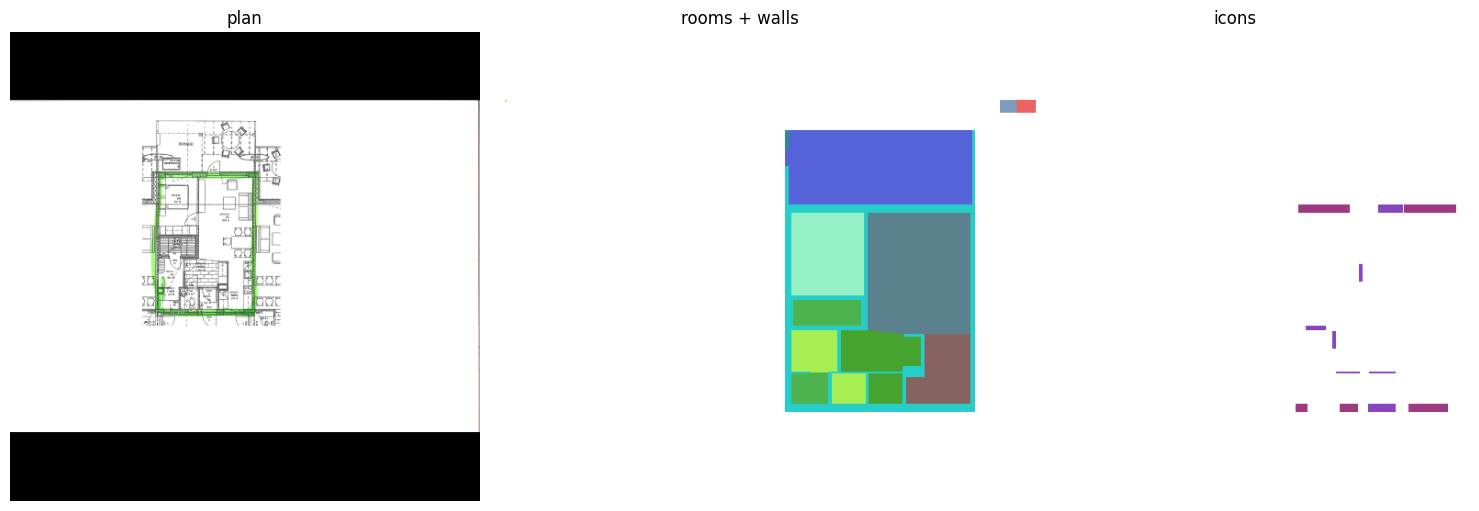

px per metre: 51.993839263916016
room classes present: ['Background', 'Outdoor', 'Wall', 'Kitchen', 'Living Room', 'Bedroom', 'Bath', 'Entry', 'Railing', 'Other Rooms']


In [12]:
# Visual sanity check of the parsed labels.
x, r, i, s = ds_train[0]
img = (x.numpy().transpose(1, 2, 0) * STD + MEAN).clip(0, 1)
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(img);                      ax[0].set_title("plan")
ax[1].imshow(colorize(r.numpy(), ROOM_PAL)); ax[1].set_title("rooms + walls")
ax[2].imshow(colorize(i.numpy(), ICON_PAL)); ax[2].set_title("icons")
for a in ax: a.axis("off")
plt.tight_layout(); plt.show()
print("px per metre:", float(s))
print("room classes present:", [ROOM_CLASSES[c] for c in np.unique(r.numpy())])

## 5. Model — shared encoder, two heads

`smp.Unet` gives us the ResNet-34 encoder + decoder; we attach a second 1×1 conv head for
icons on the same decoder features. One backbone, two label spaces, one forward pass.

In [14]:
import segmentation_models_pytorch as smp


class MultiTaskUNet(nn.Module):
    def __init__(self, n_room=N_ROOM, n_icon=N_ICON, encoder="resnet34"):
        super().__init__()
        self.net = smp.Unet(encoder, encoder_weights="imagenet",
                            in_channels=3, classes=n_room)
        dec_ch = self.net.decoder.blocks[-1].conv2[0].out_channels
        self.icon_head = nn.Conv2d(dec_ch, n_icon, kernel_size=1)

    def forward(self, x):
        feats = self.net.encoder(x)
        dec = self.net.decoder(*feats)
        return self.net.segmentation_head(dec), self.icon_head(dec)


model = MultiTaskUNet().to(DEVICE)
with torch.no_grad():
    a, b = model(torch.zeros(1, 3, IMG_SIZE, IMG_SIZE, device=DEVICE))
print("room logits", tuple(a.shape), "| icon logits", tuple(b.shape))
print("params (M):", sum(p.numel() for p in model.parameters()) / 1e6)

room logits (1, 12, 512, 512) | icon logits (1, 11, 512, 512)
params (M): 24.438151


In [15]:
# Class-balanced CE + Dice. Walls and icons are thin/rare, so Dice matters a lot here.
dice_room = smp.losses.DiceLoss(mode="multiclass", from_logits=True)
dice_icon = smp.losses.DiceLoss(mode="multiclass", from_logits=True)

room_w = torch.ones(N_ROOM); room_w[0] = 0.2; room_w[WALL_ID] = 3.0
icon_w = torch.ones(N_ICON); icon_w[0] = 0.05
ce_room = nn.CrossEntropyLoss(weight=room_w.to(DEVICE))
ce_icon = nn.CrossEntropyLoss(weight=icon_w.to(DEVICE))

def criterion(lr_, li_, tr, ti):
    l_room = ce_room(lr_, tr) + dice_room(lr_, tr)
    l_icon = ce_icon(li_, ti) + dice_icon(li_, ti)
    return l_room + 0.7 * l_icon, l_room.item(), l_icon.item()


@torch.no_grad()
def confusion(logits, target, n):
    p = logits.argmax(1).flatten()
    t = target.flatten()
    k = (t >= 0) & (t < n)
    return torch.bincount(n * t[k] + p[k], minlength=n * n).reshape(n, n)

def iou_from_cm(cm):
    cm = cm.float()
    inter = cm.diag()
    union = cm.sum(0) + cm.sum(1) - inter
    return (inter / union.clamp(min=1)), (inter.sum() / cm.sum().clamp(min=1))

print("losses & metrics ready")

losses & metrics ready


## 6. Training loop

In [16]:
EPOCHS = 10
opt = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=3e-4,
                                            total_steps=EPOCHS * len(dl_train), pct_start=0.25)
scaler = torch.cuda.amp.GradScaler(enabled=DEVICE == "cuda")
CKPT = "/content/cubicasa_multitask.pt"


def run_epoch(loader, train: bool):
    model.train(train)
    tot = n = 0.0
    cm_r = torch.zeros(N_ROOM, N_ROOM, dtype=torch.long, device=DEVICE)
    cm_i = torch.zeros(N_ICON, N_ICON, dtype=torch.long, device=DEVICE)
    for x, tr, ti, _ in loader:
        x, tr, ti = x.to(DEVICE, non_blocking=True), tr.to(DEVICE), ti.to(DEVICE)
        with torch.set_grad_enabled(train), torch.cuda.amp.autocast(enabled=DEVICE == "cuda"):
            lr_, li_ = model(x)
            loss, _, _ = criterion(lr_, li_, tr, ti)
        if train:
            opt.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()
            scaler.unscale_(opt); nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            scaler.step(opt); scaler.update(); sched.step()
        tot += loss.item() * x.size(0); n += x.size(0)
        cm_r += confusion(lr_.float(), tr, N_ROOM)
        cm_i += confusion(li_.float(), ti, N_ICON)
    iou_r, acc_r = iou_from_cm(cm_r.cpu())
    iou_i, _ = iou_from_cm(cm_i.cpu())
    return dict(loss=tot / max(n, 1), miou_room=iou_r[1:].mean().item(),
                wall_iou=iou_r[WALL_ID].item(), miou_icon=iou_i[1:].mean().item(),
                acc=acc_r.item())


best, hist = 0.0, []
for ep in range(1, EPOCHS + 1):
    t0 = time.time()
    tr_m = run_epoch(dl_train, True)
    va_m = run_epoch(dl_val, False)
    hist.append((tr_m, va_m))
    print(f"ep{ep:02d} {time.time()-t0:5.0f}s | train {tr_m['loss']:.3f} "
          f"| val {va_m['loss']:.3f} roomIoU {va_m['miou_room']:.3f} "
          f"wallIoU {va_m['wall_iou']:.3f} iconIoU {va_m['miou_icon']:.3f}")
    score = va_m["miou_room"] + va_m["miou_icon"]
    if score > best:
        best = score
        torch.save({"model": model.state_dict(), "epoch": ep, "val": va_m}, CKPT)
        print("   ↳ saved best checkpoint")

ep01   148s | train 5.544 | val 5.054 roomIoU 0.047 wallIoU 0.159 iconIoU 0.005
   ↳ saved best checkpoint
ep02   117s | train 4.547 | val 4.292 roomIoU 0.085 wallIoU 0.169 iconIoU 0.006
   ↳ saved best checkpoint
ep03   115s | train 3.900 | val 3.705 roomIoU 0.150 wallIoU 0.176 iconIoU 0.009
   ↳ saved best checkpoint
ep04   116s | train 3.544 | val 3.387 roomIoU 0.185 wallIoU 0.175 iconIoU 0.012
   ↳ saved best checkpoint
ep05   114s | train 3.330 | val 3.227 roomIoU 0.207 wallIoU 0.182 iconIoU 0.016
   ↳ saved best checkpoint
ep06   116s | train 3.191 | val 3.147 roomIoU 0.201 wallIoU 0.191 iconIoU 0.029
   ↳ saved best checkpoint
ep07   116s | train 3.094 | val 2.994 roomIoU 0.240 wallIoU 0.184 iconIoU 0.038
   ↳ saved best checkpoint
ep08   116s | train 2.998 | val 2.907 roomIoU 0.274 wallIoU 0.194 iconIoU 0.041
   ↳ saved best checkpoint
ep09   114s | train 2.930 | val 2.893 roomIoU 0.276 wallIoU 0.188 iconIoU 0.046
   ↳ saved best checkpoint
ep10   115s | train 2.884 | val 2.875

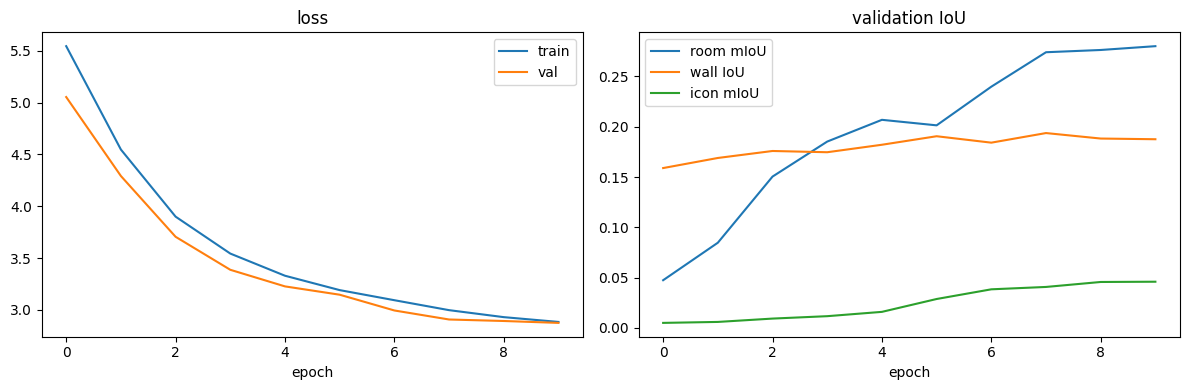

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot([h[0]["loss"] for h in hist], label="train")
ax[0].plot([h[1]["loss"] for h in hist], label="val")
ax[0].set_title("loss"); ax[0].set_xlabel("epoch"); ax[0].legend()
ax[1].plot([h[1]["miou_room"] for h in hist], label="room mIoU")
ax[1].plot([h[1]["wall_iou"] for h in hist], label="wall IoU")
ax[1].plot([h[1]["miou_icon"] for h in hist], label="icon mIoU")
ax[1].set_title("validation IoU"); ax[1].set_xlabel("epoch"); ax[1].legend()
plt.tight_layout(); plt.show()

## 7. Per-class evaluation on the test split

Task-1 metric: per-class IoU for rooms and walls. Task-2 metric: per-class IoU for icons
plus a detection-style precision/recall at IoU 0.5 computed from extracted instances.

In [18]:
model.load_state_dict(torch.load(CKPT, map_location=DEVICE)["model"])
model.eval()

ds_test = CubiCasa(test_ids[:200], SPLIT_BASE, eval_tf)
dl_test = DataLoader(ds_test, batch_size=6, num_workers=2)

cm_r = torch.zeros(N_ROOM, N_ROOM, dtype=torch.long)
cm_i = torch.zeros(N_ICON, N_ICON, dtype=torch.long)
with torch.no_grad():
    for x, tr, ti, _ in dl_test:
        lr_, li_ = model(x.to(DEVICE))
        cm_r += confusion(lr_.float().cpu(), tr, N_ROOM)
        cm_i += confusion(li_.float().cpu(), ti, N_ICON)

iou_r, acc = iou_from_cm(cm_r)
iou_i, _   = iou_from_cm(cm_i)
print(f"pixel accuracy (rooms): {acc:.3f}\n")
print("── room / wall IoU ──")
for c, v in zip(ROOM_CLASSES, iou_r.tolist()):
    print(f"  {c:<14s} {v:.3f}")
print(f"  {'mean (fg)':<14s} {iou_r[1:].mean():.3f}")
print("\n── icon IoU ──")
for c, v in zip(ICON_CLASSES, iou_i.tolist()):
    print(f"  {c:<14s} {v:.3f}")
print(f"  {'mean (fg)':<14s} {iou_i[1:].mean():.3f}")

200/200 samples usable
pixel accuracy (rooms): 0.646

── room / wall IoU ──
  Background     0.751
  Outdoor        0.429
  Wall           0.191
  Kitchen        0.437
  Living Room    0.525
  Bedroom        0.434
  Bath           0.267
  Entry          0.324
  Railing        0.000
  Storage        0.000
  Garage         0.196
  Other Rooms    0.161
  mean (fg)      0.269

── icon IoU ──
  No Icon        0.910
  Window         0.125
  Door           0.061
  Closet         0.098
  Electr. Appl.  0.125
  Toilet         0.000
  Sink           0.000
  Sauna Bench    0.000
  Fire Place     0.000
  Bathtub        0.000
  Chimney        0.000
  mean (fg)      0.041


## 8. Task 2 — icon **detection**: instances & boxes

The icon head gives per-pixel classes; we turn them into detections with connected
components per class, then score them against ground-truth instances at IoU 0.5.

In [19]:
MIN_ICON_AREA = 60

def icon_instances(icon_mask, min_area=MIN_ICON_AREA):
    """Connected components per icon class -> [{cls, box, area, mask}]."""
    dets = []
    for cid in range(1, N_ICON):
        binm = (icon_mask == cid).astype(np.uint8)
        if binm.sum() < min_area:
            continue
        n, lab, stats, cent = cv2.connectedComponentsWithStats(binm, connectivity=8)
        for k in range(1, n):
            x, y, w, h, area = stats[k]
            if area < min_area:
                continue
            dets.append({"cls": cid, "name": ICON_CLASSES[cid],
                         "box": [int(x), int(y), int(x + w), int(y + h)],
                         "area_px": int(area),
                         "center": [float(cent[k][0]), float(cent[k][1])],
                         "mask": (lab == k)})
    return dets


def box_iou(a, b):
    ix1, iy1 = max(a[0], b[0]), max(a[1], b[1])
    ix2, iy2 = min(a[2], b[2]), min(a[3], b[3])
    iw, ih = max(0, ix2 - ix1), max(0, iy2 - iy1)
    inter = iw * ih
    ua = (a[2]-a[0])*(a[3]-a[1]) + (b[2]-b[0])*(b[3]-b[1]) - inter
    return inter / ua if ua > 0 else 0.0


tp = defaultdict(int); fp = defaultdict(int); fn = defaultdict(int)
with torch.no_grad():
    for x, tr, ti, _ in dl_test:
        pred = model(x.to(DEVICE))[1].argmax(1).cpu().numpy()
        gt = ti.numpy()
        for p, g in zip(pred, gt):
            P, G = icon_instances(p), icon_instances(g)
            used = set()
            for d in P:
                best_j, best_v = -1, 0.0
                for j, t in enumerate(G):
                    if j in used or t["cls"] != d["cls"]:
                        continue
                    v = box_iou(d["box"], t["box"])
                    if v > best_v:
                        best_v, best_j = v, j
                if best_v >= 0.5:
                    tp[d["cls"]] += 1; used.add(best_j)
                else:
                    fp[d["cls"]] += 1
            for j, t in enumerate(G):
                if j not in used:
                    fn[t["cls"]] += 1

print(f"{'icon':<14s} {'P':>6s} {'R':>6s} {'F1':>6s}   (IoU@0.5)")
f1s = []
for cid in range(1, N_ICON):
    P = tp[cid] / max(tp[cid] + fp[cid], 1)
    R = tp[cid] / max(tp[cid] + fn[cid], 1)
    F = 2 * P * R / max(P + R, 1e-9)
    f1s.append(F)
    print(f"{ICON_CLASSES[cid]:<14s} {P:6.3f} {R:6.3f} {F:6.3f}")
print(f"{'mean F1':<14s} {'':6s} {'':6s} {np.mean(f1s):6.3f}")

icon                P      R     F1   (IoU@0.5)
Window          0.003  0.002  0.002
Door            0.022  0.005  0.008
Closet          0.018  0.055  0.027
Electr. Appl.   0.065  0.292  0.106
Toilet          0.000  0.000  0.000
Sink            0.000  0.000  0.000
Sauna Bench     0.000  0.000  0.000
Fire Place      0.000  0.000  0.000
Bathtub         0.000  0.000  0.000
Chimney         0.000  0.000  0.000
mean F1                       0.014


## 9. Tasks 3 & 4 — room instances, areas, and vectorized JSON

Pipeline:

1. **Room instances** — remove walls, take connected components of the floor region,
   apply a watershed-style opening to split rooms that touch through doorways.
2. **Classification** — majority vote of the room head inside each instance (task 3).
3. **Area** — pixel count ÷ `px_per_m²`, reported in m² (task 3).
4. **Vectorization** — `findContours` → `approxPolyDP` → rectilinear snapping, plus wall
   centerline extraction via skeletonisation, emitted as a single JSON document (task 4).

In [24]:
MIN_ROOM_PX = 500

def room_instances(room_mask):
    """Split the floor region into room polygons with a majority-vote class."""
    structural = np.isin(room_mask, [ROOM_CLASSES.index("Wall"),
                                     ROOM_CLASSES.index("Railing")])
    floor = ((room_mask > 0) & ~structural).astype(np.uint8)
    # Opening severs thin doorway connections between adjacent rooms.
    floor = cv2.morphologyEx(floor, cv2.MORPH_OPEN, np.ones((5, 5), np.uint8))
    n, lab = cv2.connectedComponents(floor, connectivity=4)
    out = []
    for k in range(1, n):
        m = lab == k
        if m.sum() < MIN_ROOM_PX:
            continue
        votes = Counter(room_mask[m].tolist())
        votes.pop(0, None)
        for sid in (ROOM_CLASSES.index("Wall"), ROOM_CLASSES.index("Railing")):
            votes.pop(sid, None)
        cid = votes.most_common(1)[0][0] if votes else ROOM_CLASSES.index("Other Rooms")
        out.append({"cls": int(cid), "name": ROOM_CLASSES[cid],
                    "area_px": int(m.sum()), "mask": m})
    return out


def snap_rectilinear(pts, tol=6):
    """Floor plans are axis-aligned; nudge near-vertical/horizontal edges flat."""
    q = pts.astype(np.float32).copy()
    for i in range(len(q)):
        j = (i + 1) % len(q)
        dx, dy = q[j, 0] - q[i, 0], q[j, 1] - q[i, 1]
        if abs(dx) < tol and abs(dx) < abs(dy):
            q[j, 0] = q[i, 0]
        elif abs(dy) < tol and abs(dy) < abs(dx):
            q[j, 1] = q[i, 1]
    return q


def mask_to_polygon(mask, eps_frac=0.008, snap=True):
    cnts, _ = cv2.findContours(mask.astype(np.uint8), cv2.RETR_EXTERNAL,
                              cv2.CHAIN_APPROX_SIMPLE)
    if not cnts:
        return None
    c = max(cnts, key=cv2.contourArea)
    approx = cv2.approxPolyDP(c, eps_frac * cv2.arcLength(c, True), True).reshape(-1, 2)
    if snap and len(approx) >= 4:
        approx = snap_rectilinear(approx)
    return np.round(approx).astype(int)


def wall_segments(room_mask, min_len=15):
    """Wall centerlines as line segments via probabilistic Hough on a thinned mask."""
    wall = (room_mask == WALL_ID).astype(np.uint8) * 255
    wall = cv2.morphologyEx(wall, cv2.MORPH_CLOSE, np.ones((3, 3), np.uint8))
    try:
        thin = cv2.ximgproc.thinning(wall)
    except Exception:
        thin = cv2.Canny(wall, 50, 150)

    lines = cv2.HoughLinesP(thin, 1, np.pi / 180, threshold=30,
                            minLineLength=min_len, maxLineGap=6)

    if lines is None:
        return []

    # Reshape lines from (N, 1, 4) to (N, 4) safely
    lines = lines.reshape(-1, 4)
    return [line.astype(int).tolist() for line in lines]


def vectorize(room_mask, icon_mask, px_per_m, plan_id="plan"):
    """Full structured output: rooms (typed + area), icons, wall segments, totals."""
    px2 = max(px_per_m, 1e-6) ** 2
    rooms = []
    for idx, r in enumerate(room_instances(room_mask)):
        poly = mask_to_polygon(r["mask"])
        if poly is None or len(poly) < 3:
            continue
        ys, xs = np.where(r["mask"])
        rooms.append({
            "id": f"room_{idx}",
            "type": r["name"],
            "area_m2": round(r["area_px"] / px2, 2),
            "area_px": r["area_px"],
            "bbox": [int(xs.min()), int(ys.min()), int(xs.max()), int(ys.max())],
            "centroid": [float(xs.mean()), float(ys.mean())],
            "polygon": poly.tolist(),
        })

    icons = []
    for idx, d in enumerate(icon_instances(icon_mask)):
        poly = mask_to_polygon(d["mask"], eps_frac=0.02, snap=False)
        icons.append({
            "id": f"icon_{idx}", "type": d["name"], "bbox": d["box"],
            "center": [round(v, 1) for v in d["center"]],
            "width_m": round((d["box"][2] - d["box"][0]) / max(px_per_m, 1e-6), 2),
            "polygon": (poly.tolist() if poly is not None else None),
        })

    walls = [{"id": f"wall_{k}", "start": s[:2], "end": s[2:],
              "length_m": round(math.dist(s[:2], s[2:]) / max(px_per_m, 1e-6), 2)}
             for k, s in enumerate(wall_segments(room_mask))]

    habitable = sum(r["area_m2"] for r in rooms if r["type"] in AREA_ROOMS)
    return {
        "plan_id": plan_id,
        "units": "metres",
        "scale": {"pixels_per_metre": round(float(px_per_m), 2)},
        "image_size": list(room_mask.shape[::-1]),
        "summary": {
            "room_count": len(rooms),
            "icon_count": len(icons),
            "wall_segment_count": len(walls),
            "habitable_area_m2": round(habitable, 2),
            "total_enclosed_area_m2": round(sum(r["area_m2"] for r in rooms), 2),
            "rooms_by_type": dict(Counter(r["type"] for r in rooms)),
            "icons_by_type": dict(Counter(i["type"] for i in icons)),
        },
        "rooms": rooms, "icons": icons, "walls": walls,
    }

print("vectorizer ready")

vectorizer ready


## 10. Full inference on one plan — all four tasks together

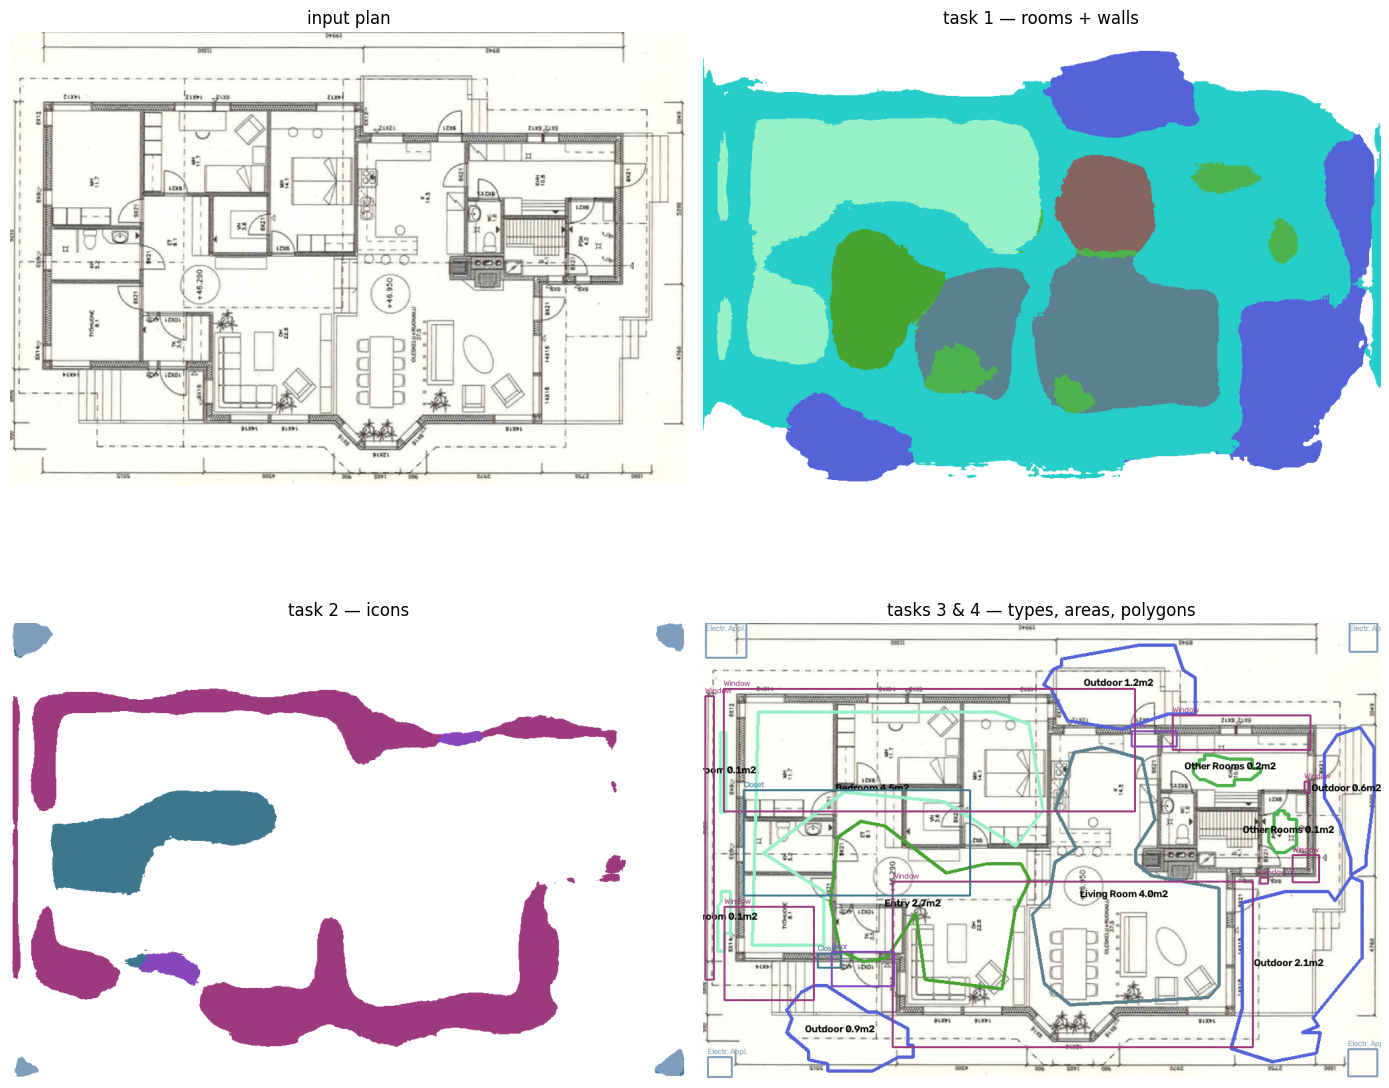

{
  "plan_id": "high_quality_architectural__1191",
  "units": "metres",
  "scale": {
    "pixels_per_metre": 135.57
  },
  "image_size": [
    1024,
    687
  ],
  "summary": {
    "room_count": 11,
    "icon_count": 16,
    "wall_segment_count": 147,
    "habitable_area_m2": 11.66,
    "total_enclosed_area_m2": 16.57,
    "rooms_by_type": {
      "Outdoor": 4,
      "Bedroom": 3,
      "Living Room": 1,
      "Other Rooms": 2,
      "Entry": 1
    },
    "icons_by_type": {
      "Window": 8,
      "Door": 2,
      "Closet": 2,
      "Electr. Appl.": 4
    }
  },
  "rooms": [
    {
      "id": "room_0",
      "type": "Outdoor",
      "area_m2": 1.24,
      "area_px": 22860,
      "bbox": [
        514,
        30,
        748,
        160
      ],
      "centroid": [
        635.0563867016623,
        95.67248468941382
      ],
      "polygon": [
        [
          743,
          82
        ],
        [
          725,
          71
        ],
        [
          712,
          33
     

In [25]:
@torch.no_grad()
def predict(img_rgb):
    """Returns (room_mask, icon_mask) at the original image resolution."""
    import torch.nn.functional as F  # Re-bind F to torch.nn.functional to prevent variable shadowing

    H, W = img_rgb.shape[:2]
    t = eval_tf(image=img_rgb, mask=np.zeros((H, W), np.uint8),
                icon=np.zeros((H, W), np.uint8))
    x = ((t["image"].astype(np.float32) / 255.0) - MEAN) / STD
    x = torch.from_numpy(x.transpose(2, 0, 1))[None].to(DEVICE)
    lr_, li_ = model(x)

    # Undo letterbox padding and resize back to original resolution
    s = IMG_SIZE / max(H, W)
    nh, nw = int(round(H * s)), int(round(W * s))
    top, left = (IMG_SIZE - nh) // 2, (IMG_SIZE - nw) // 2

    def back(logits):
        crop = logits[0, :, top:top + nh, left:left + nw][None]
        return F.interpolate(crop, size=(H, W), mode="bilinear",
                             align_corners=False).argmax(1)[0].cpu().numpy().astype(np.uint8)

    return back(lr_), back(li_)


def draw_overlay(img, result):
    vis = img.copy()
    for r in result["rooms"]:
        p = np.array(r["polygon"], np.int32)
        col = tuple(int(255 * c) for c in ROOM_PAL[ROOM_CLASSES.index(r["type"])])
        cv2.polylines(vis, [p], True, col, 3)
        cx, cy = map(int, r["centroid"])
        cv2.putText(vis, f'{r["type"]} {r["area_m2"]:.1f}m2', (cx - 60, cy),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 2, cv2.LINE_AA)
    for d in result["icons"]:
        x1, y1, x2, y2 = d["bbox"]
        col = tuple(int(255 * c) for c in ICON_PAL[ICON_CLASSES.index(d["type"])])
        cv2.rectangle(vis, (x1, y1), (x2, y2), col, 2)
        cv2.putText(vis, d["type"], (x1, max(12, y1 - 4)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.4, col, 1, cv2.LINE_AA)
    return vis


# ---- run on a held-out test plan -------------------------------------------
img_path, svg_path, key = ds_test.items[0]
img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
if max(img.shape[:2]) > 1024:
    sc = 1024 / max(img.shape[:2])
    img = cv2.resize(img, None, fx=sc, fy=sc, interpolation=cv2.INTER_AREA)

gt_room, gt_icon, meta = parse_svg(svg_path, img.shape[:2])
pred_room, pred_icon = predict(img)
result = vectorize(pred_room, pred_icon, meta["px_per_m"], plan_id=key)

fig, ax = plt.subplots(2, 2, figsize=(14, 13))
ax[0, 0].imshow(img);                                ax[0, 0].set_title("input plan")
ax[0, 1].imshow(colorize(pred_room, ROOM_PAL));      ax[0, 1].set_title("task 1 — rooms + walls")
ax[1, 0].imshow(colorize(pred_icon, ICON_PAL));      ax[1, 0].set_title("task 2 — icons")
ax[1, 1].imshow(draw_overlay(img, result));          ax[1, 1].set_title("tasks 3 & 4 — types, areas, polygons")
for a in ax.ravel(): a.axis("off")
plt.tight_layout(); plt.show()

print(json.dumps({k: v for k, v in result.items() if k != "walls"}, indent=2)[:2500])

In [26]:
# Persist the structured output (task 4 deliverable).
out_path = f"/content/{result['plan_id']}_floorplan.json"
Path(out_path).write_text(json.dumps(result, indent=2))
print("wrote", out_path)
print("\nsummary:")
print(json.dumps(result["summary"], indent=2))

# from google.colab import files; files.download(out_path)

wrote /content/high_quality_architectural__1191_floorplan.json

summary:
{
  "room_count": 11,
  "icon_count": 16,
  "wall_segment_count": 147,
  "habitable_area_m2": 11.66,
  "total_enclosed_area_m2": 16.57,
  "rooms_by_type": {
    "Outdoor": 4,
    "Bedroom": 3,
    "Living Room": 1,
    "Other Rooms": 2,
    "Entry": 1
  },
  "icons_by_type": {
    "Window": 8,
    "Door": 2,
    "Closet": 2,
    "Electr. Appl.": 4
  }
}


## 11. Batch export — run the whole pipeline over the test split

In [27]:
from tqdm.auto import tqdm

EXPORT_DIR = Path("/content/exports"); EXPORT_DIR.mkdir(exist_ok=True)
rows = []

for img_path, svg_path, key in tqdm(ds_test.items[:50], desc="vectorizing"):
    im = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    if max(im.shape[:2]) > 1024:
        sc = 1024 / max(im.shape[:2])
        im = cv2.resize(im, None, fx=sc, fy=sc, interpolation=cv2.INTER_AREA)
    _, _, m = parse_svg(svg_path, im.shape[:2])
    pr, pi = predict(im)
    res = vectorize(pr, pi, m["px_per_m"], plan_id=key)
    (EXPORT_DIR / f"{key}.json").write_text(json.dumps(res))
    rows.append({"plan": key, **res["summary"]})

import pandas as pd
df = pd.DataFrame(rows)
df.to_csv("/content/floorplan_summary.csv", index=False)
display(df.head(15))
print("\nmean habitable area (m2):", round(df["habitable_area_m2"].mean(), 1))
print("mean rooms per plan:", round(df["room_count"].mean(), 1))

vectorizing:   0%|          | 0/50 [00:00<?, ?it/s]

,plan,room_count,icon_count,wall_segment_count,habitable_area_m2,total_enclosed_area_m2,rooms_by_type,icons_by_type
0,high_quality_architectural__1191,11,16,147,11.66,16.57,"{'Outdoor': 4, 'Bedroom': 3, 'Living Room': 1,...","{'Window': 8, 'Door': 2, 'Closet': 2, 'Electr...."
1,high_quality_architectural__2536,4,18,144,43.42,46.52,"{'Outdoor': 1, 'Bedroom': 1, 'Bath': 2}","{'Window': 4, 'Door': 3, 'Closet': 6, 'Electr...."
2,high_quality_architectural__2530,6,18,123,42.28,61.46,"{'Outdoor': 2, 'Living Room': 1, 'Other Rooms'...","{'Window': 7, 'Door': 1, 'Closet': 6, 'Electr...."
3,high_quality_architectural__2504,6,14,123,12.57,15.90,"{'Living Room': 1, 'Other Rooms': 1, 'Bath': 1...","{'Window': 3, 'Door': 1, 'Closet': 6, 'Electr...."
4,high_quality_architectural__2207,5,17,106,6.27,10.93,"{'Outdoor': 2, 'Bedroom': 2, 'Garage': 1}","{'Window': 6, 'Door': 3, 'Closet': 5, 'Electr...."
5,high_quality_architectural__22,6,20,168,105.22,130.02,"{'Bedroom': 2, 'Outdoor': 2, 'Garage': 1, 'Oth...","{'Window': 7, 'Door': 2, 'Closet': 8, 'Electr...."
6,high_quality_architectural__2090,4,15,142,7.99,9.55,"{'Outdoor': 1, 'Bedroom': 1, 'Living Room': 1,...","{'Window': 4, 'Door': 1, 'Closet': 6, 'Electr...."
7,high_quality_architectural__2085,7,24,153,17.60,19.64,"{'Outdoor': 3, 'Bedroom': 2, 'Living Room': 1,...","{'Window': 8, 'Door': 5, 'Closet': 7, 'Electr...."
8,high_quality_architectural__2014,8,19,167,14.98,19.48,"{'Bedroom': 1, 'Outdoor': 3, 'Garage': 1, 'Oth...","{'Window': 5, 'Door': 2, 'Closet': 8, 'Electr...."
9,high_quality_architectural__2011,10,23,215,19.30,25.03,"{'Outdoor': 3, 'Bedroom': 3, 'Living Room': 2,...","{'Window': 7, 'Door': 3, 'Closet': 9, 'Electr...."



mean habitable area (m2): 29.8
mean rooms per plan: 6.2


## 12. Notes for pushing accuracy further

- **Use the full split.** Set `N_TRAIN = len(train_ids)` and `EPOCHS = 40`. Label
  rasterisation is cached to `/content/cache`, so epoch 2 onward is GPU-bound. Mount Drive
  and point `cache_dir` there to keep the cache across sessions.
- **Resolution matters most.** Walls are 3–6 px wide at 512²; training at 768² or 1024²
  typically adds several IoU points on `Wall` and on small icons like `Sink`.
- **Stronger encoder.** `MultiTaskUNet(encoder="resnext50_32x4d")` or an
  `smp.DeepLabV3Plus` backbone if memory allows; drop batch size to 3–4.
- **Heatmap head for icons.** The original paper regresses corner heatmaps for fixtures,
  which localises better than segmentation for tiny objects — add a third head predicting
  Gaussian keypoints and decode with non-maximum suppression.
- **Scale estimation.** The `px_per_m` here is inferred from median wall thickness. If your
  plans carry a dimension string or a scale bar, OCR it (`pytesseract`) and override
  `px_per_m` — area accuracy is bounded almost entirely by this factor.
- **Post-processing.** Snapping room polygons to a shared wall graph (instead of per-room
  contours) removes the small gaps between adjacent rooms and yields watertight geometry
  suitable for CAD/IFC export.